# Amazon Product Exploratory Data Analysis

## Project
Amazon Germany Wireless Headphones Price and Competitor Intelligence

## Objective
This notebook connects to PostgreSQL, retrieves the latest Amazon product observations, calculates business KPIs, creates exploratory charts and identifies useful competitor and pricing insights.

## Import Libraries

In [2]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dotenv import load_dotenv
from sqlalchemy import create_engine, text
from sqlalchemy.engine import URL

print("Libraries imported successfully.")

Libraries imported successfully.


## Connect to PostgreSQL
## Define project paths

In [3]:
PROJECT_ROOT = Path.cwd().parent
ENV_FILE = PROJECT_ROOT / ".env"
EXPORT_DIR = PROJECT_ROOT / "data" / "exports"

EXPORT_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Environment file exists:", ENV_FILE.exists())
print("Export folder:", EXPORT_DIR)

Project root: C:\Users\srika\Documents\Srikanth_Amazon_BI_Project
Environment file exists: True
Export folder: C:\Users\srika\Documents\Srikanth_Amazon_BI_Project\data\exports


## Load database credentials

In [4]:
load_dotenv(ENV_FILE)

DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT", "5432")
DB_NAME = os.getenv("DB_NAME")
DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")

if not all([
    DB_HOST,
    DB_PORT,
    DB_NAME,
    DB_USER,
    DB_PASSWORD
]):
    raise ValueError(
        "One or more database settings are missing from .env."
    )

print("Database settings loaded successfully.")
print("Database name:", DB_NAME)
print("Password is hidden.")

Database settings loaded successfully.
Database name: amazon_competitor_bi
Password is hidden.


## Create the database engine

In [5]:
database_url = URL.create(
    drivername="postgresql+psycopg2",
    username=DB_USER,
    password=DB_PASSWORD,
    host=DB_HOST,
    port=int(DB_PORT),
    database=DB_NAME
)

engine = create_engine(
    database_url,
    pool_pre_ping=True
)

print("Database engine created successfully.")

Database engine created successfully.


## Test the connection 

In [7]:
with engine.connect() as connection:
    connection_test = connection.execute(
        text("""
            SELECT
                current_database() AS database_name,
                current_user AS database_user;
        """)
    ).mappings().one()

print("PostgreSQL connection successful.")
print("Database:", connection_test["database_name"])
print("User:", connection_test["database_user"])

PostgreSQL connection successful.
Database: amazon_competitor_bi
User: postgres


## Load the Latest Product Data

Because the pipeline may run several times, the fact table can contain multiple observations for the same product. We should analyse only the latest observation for each ASIN.

## Load the latest observation per product

In [8]:
latest_products_query = text("""
    WITH ranked_observations AS (
        SELECT
            f.*,
            ROW_NUMBER() OVER (
                PARTITION BY f.asin
                ORDER BY f.extraction_timestamp DESC
            ) AS row_number
        FROM fact_product_observations f
    )

    SELECT
        p.asin,
        p.product_title,
        p.brand,
        p.product_url,
        p.image_url,
        p.marketplace,
        p.search_query,
        r.current_price,
        r.original_price,
        r.currency,
        r.discount_percentage,
        r.price_category,
        r.rating,
        r.rating_category,
        r.review_count,
        r.search_position,
        r.is_prime,
        r.is_sponsored,
        r.extraction_date,
        r.extraction_timestamp
    FROM ranked_observations r
    JOIN dim_products p
        ON r.asin = p.asin
    WHERE r.row_number = 1
    ORDER BY p.brand, p.product_title;
""")

with engine.connect() as connection:
    products_df = pd.read_sql(
        latest_products_query,
        connection
    )

print("Latest product data loaded successfully.")
print("Rows:", products_df.shape[0])
print("Columns:", products_df.shape[1])

display(products_df.head())

Latest product data loaded successfully.
Rows: 32
Columns: 20


,asin,product_title,brand,product_url,image_url,marketplace,search_query,current_price,original_price,currency,discount_percentage,price_category,rating,rating_category,review_count,search_position,is_prime,is_sponsored,extraction_date,extraction_timestamp
0,B0DGHWD7CT,"Apple AirPods 4 Kabellose Kopfhörer, Bluetooth...",Apple,https://www.amazon.de/Apple-Kabellose-Kopfh%C3...,https://m.media-amazon.com/images/I/61DvMw16IT...,Amazon Germany,wireless headphones,116.00,None,EUR,0.0,Premium,4.6,Excellent,13612,None,False,False,2026-06-17,2026-06-17 21:49:06.632617
1,B0FDL13R3J,"Fachixy FC100 Headset mit Mikrofon, 2,4G Wirel...",Fachixy,https://www.amazon.de/sspa/click?ie=UTF8&spc=M...,https://m.media-amazon.com/images/I/71FY+0r5Io...,Amazon Germany,wireless headphones,35.66,None,EUR,0.0,Mid-range,4.3,Good,374,None,False,False,2026-06-17,2026-06-17 15:54:20.345120
2,B0BYWMLVG1,JBL Tune 520 BT Wireless On-Ear Kopfhörer – Mi...,JBL,https://www.amazon.de/JBL-Tune-520BT-Wireless-...,https://m.media-amazon.com/images/I/512LuQyL3B...,Amazon Germany,wireless headphones,34.99,None,EUR,0.0,Mid-range,4.6,Excellent,11360,None,False,False,2026-06-17,2026-06-17 20:50:58.841211
3,B0FV3VX75R,JBL Tune 680 NC Kabellose On-Ear-Kopfhörer mit...,JBL,https://www.amazon.de/sspa/click?ie=UTF8&spc=M...,https://m.media-amazon.com/images/I/61wuPFetlI...,Amazon Germany,wireless headphones,77.99,None,EUR,0.0,Premium,4.3,Good,129,None,False,False,2026-06-17,2026-06-17 20:50:58.841211
4,B0FSH42VZW,JBL Tune 730 BT Wireless Over-Ear-Kopfhörermit...,JBL,https://www.amazon.de/JBL-Over-Ear-Kopfh%C3%B6...,https://m.media-amazon.com/images/I/61WyJZWEhz...,Amazon Germany,wireless headphones,59.99,None,EUR,0.0,Mid-range,4.4,Good,464,None,False,False,2026-06-17,2026-06-17 21:49:06.632617


## Inspect the dataset

In [9]:
products_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   asin                  32 non-null     str           
 1   product_title         32 non-null     str           
 2   brand                 32 non-null     str           
 3   product_url           32 non-null     str           
 4   image_url             32 non-null     str           
 5   marketplace           32 non-null     str           
 6   search_query          32 non-null     str           
 7   current_price         32 non-null     float64       
 8   original_price        0 non-null      object        
 9   currency              32 non-null     str           
 10  discount_percentage   32 non-null     float64       
 11  price_category        32 non-null     str           
 12  rating                32 non-null     float64       
 13  rating_category       32 non-null

In [10]:
display(
    products_df.isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame(name="missing_values")
)

,missing_values
search_position,32
original_price,32
asin,0
product_title,0
product_url,0
brand,0
search_query,0
image_url,0
current_price,0
currency,0


## Main KPI Analysis
## Calculate KPI values

In [11]:
kpi_summary = {
    "Total Unique Products": products_df["asin"].nunique(),
    "Total Brands": products_df["brand"].nunique(),
    "Average Price (€)": round(
        products_df["current_price"].mean(),
        2
    ),
    "Minimum Price (€)": round(
        products_df["current_price"].min(),
        2
    ),
    "Maximum Price (€)": round(
        products_df["current_price"].max(),
        2
    ),
    "Average Rating": round(
        products_df["rating"].mean(),
        2
    ),
    "Total Reviews": int(
        products_df["review_count"].sum()
    ),
    "Prime Products": int(
        products_df["is_prime"].sum()
    ),
    "Sponsored Products": int(
        products_df["is_sponsored"].sum()
    )
}

kpi_summary_df = pd.DataFrame(
    kpi_summary.items(),
    columns=["KPI", "Value"]
)

display(kpi_summary_df)

,KPI,Value
0,Total Unique Products,32.00
1,Total Brands,8.00
2,Average Price (€),59.66
3,Minimum Price (€),10.99
4,Maximum Price (€),689.00
5,Average Rating,4.47
6,Total Reviews,701462.00
7,Prime Products,0.00
8,Sponsored Products,0.00


## Brand Analysis
## Products by brand

In [12]:
brand_product_count = (
    products_df
    .groupby("brand", as_index=False)
    .agg(
        product_count=("asin", "nunique")
    )
    .sort_values(
        by="product_count",
        ascending=False
    )
)

display(brand_product_count)

,brand,product_count
6,Unknown,12
2,JBL,7
5,Soundcore,6
4,Sony,3
3,Samsung,1
1,Fachixy,1
0,Apple,1
7,ZZU,1


## Plot products by brand

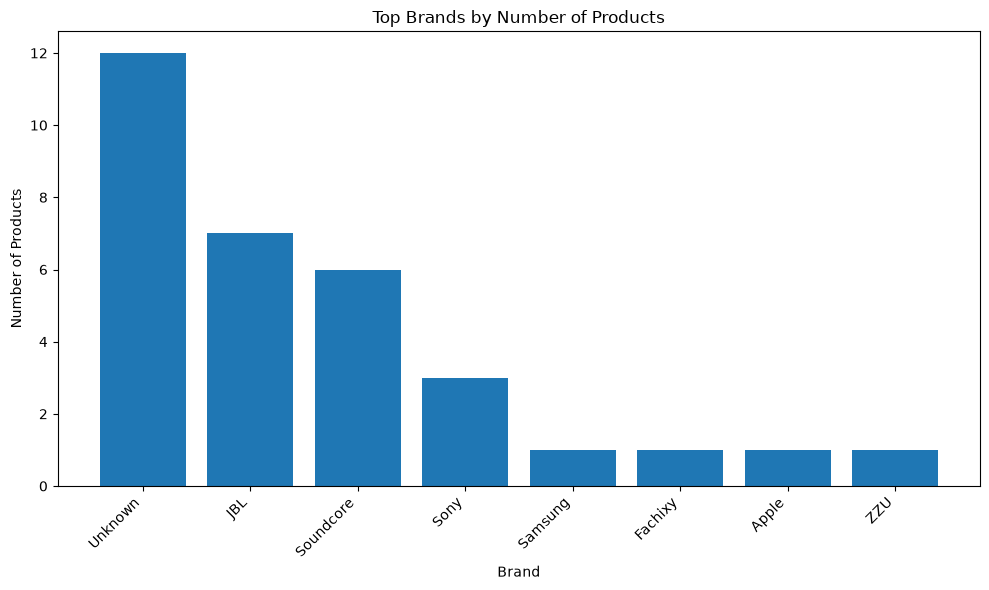

In [14]:
brand_plot_df = brand_product_count.head(10)

plt.figure(figsize=(10, 6))

plt.bar(
    brand_plot_df["brand"],
    brand_plot_df["product_count"]
)

plt.title("Top Brands by Number of Products")
plt.xlabel("Brand")
plt.ylabel("Number of Products")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Brand performance table

In [15]:
brand_performance_df = (
    products_df
    .groupby("brand", as_index=False)
    .agg(
        product_count=("asin", "nunique"),
        average_price=("current_price", "mean"),
        minimum_price=("current_price", "min"),
        maximum_price=("current_price", "max"),
        average_rating=("rating", "mean"),
        total_reviews=("review_count", "sum")
    )
)

brand_performance_df[
    [
        "average_price",
        "minimum_price",
        "maximum_price",
        "average_rating"
    ]
] = brand_performance_df[
    [
        "average_price",
        "minimum_price",
        "maximum_price",
        "average_rating"
    ]
].round(2)

brand_performance_df = brand_performance_df.sort_values(
    by="average_price",
    ascending=False
)

display(brand_performance_df)

,brand,product_count,average_price,minimum_price,maximum_price,average_rating,total_reviews
0,Apple,1,116.00,116.00,116.00,4.60,13612
6,Unknown,12,82.33,15.97,689.00,4.59,135219
2,JBL,7,63.16,34.99,92.13,4.33,30958
4,Sony,3,39.52,29.00,59.99,4.50,102579
1,Fachixy,1,35.66,35.66,35.66,4.30,374
5,Soundcore,6,30.74,19.99,56.00,4.42,415266
7,ZZU,1,13.29,13.29,13.29,4.50,2211
3,Samsung,1,10.99,10.99,10.99,4.40,1243


## Price descriptive statistics

In [16]:
price_statistics_df = (
    products_df["current_price"]
    .describe()
    .round(2)
    .to_frame(name="current_price")
)

display(price_statistics_df)

,current_price
count,32.00
mean,59.66
std,117.33
min,10.99
25%,24.86
50%,29.78
75%,51.50
max,689.00


## Price distribution histogram

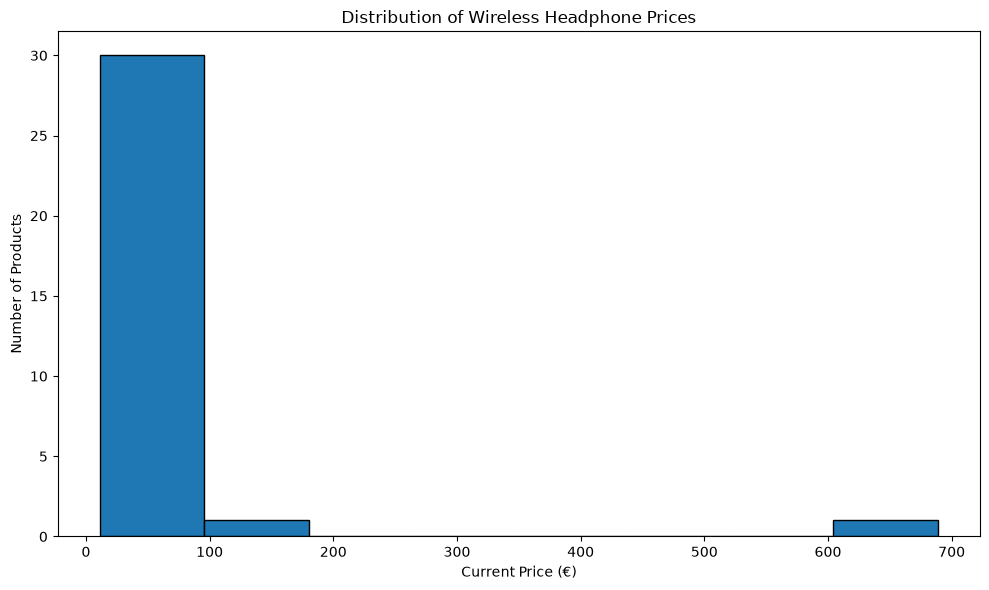

In [18]:
plt.figure(figsize=(10, 6))

plt.hist(
    products_df["current_price"].dropna(),
    bins=8,
    edgecolor="black"
)

plt.title("Distribution of Wireless Headphone Prices")
plt.xlabel("Current Price (€)")
plt.ylabel("Number of Products")
plt.tight_layout()
plt.show()

## Price-category analysis

In [19]:
price_category_summary = (
    products_df
    .groupby(
        "price_category",
        observed=True,
        as_index=False
    )
    .agg(
        product_count=("asin", "nunique"),
        average_price=("current_price", "mean"),
        average_rating=("rating", "mean"),
        total_reviews=("review_count", "sum")
    )
)

price_category_summary[
    ["average_price", "average_rating"]
] = price_category_summary[
    ["average_price", "average_rating"]
].round(2)

display(price_category_summary)

,price_category,product_count,average_price,average_rating,total_reviews
0,Budget,18,23.85,4.51,610306
1,Luxury,1,689.00,4.50,420
2,Mid-range,9,47.40,4.42,74466
3,Premium,4,91.03,4.42,16270


## Price-category chart

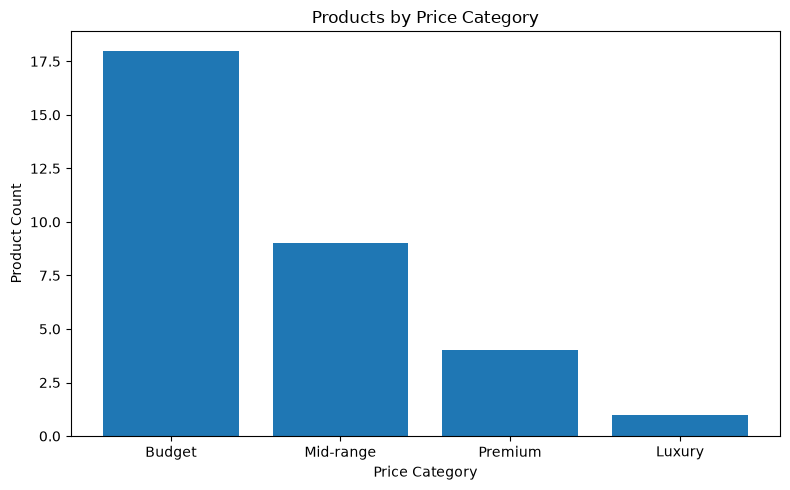

In [20]:
price_category_order = [
    "Budget",
    "Mid-range",
    "Premium",
    "Luxury"
]

price_category_chart_df = (
    products_df["price_category"]
    .value_counts()
    .reindex(
        price_category_order,
        fill_value=0
    )
)

plt.figure(figsize=(8, 5))

plt.bar(
    price_category_chart_df.index,
    price_category_chart_df.values
)

plt.title("Products by Price Category")
plt.xlabel("Price Category")
plt.ylabel("Product Count")
plt.tight_layout()
plt.show()

## Rating-category summary

In [21]:
rating_category_summary = (
    products_df
    .groupby(
        "rating_category",
        observed=True,
        as_index=False
    )
    .agg(
        product_count=("asin", "nunique"),
        average_rating=("rating", "mean"),
        average_price=("current_price", "mean"),
        total_reviews=("review_count", "sum")
    )
)

rating_category_summary[
    ["average_rating", "average_price"]
] = rating_category_summary[
    ["average_rating", "average_price"]
].round(2)

display(rating_category_summary)

,rating_category,product_count,average_rating,average_price,total_reviews
0,Average,1,4.00,50.00,9046
1,Excellent,10,4.71,38.04,174757
2,Good,21,4.39,70.41,517659


## Rating distribution chart

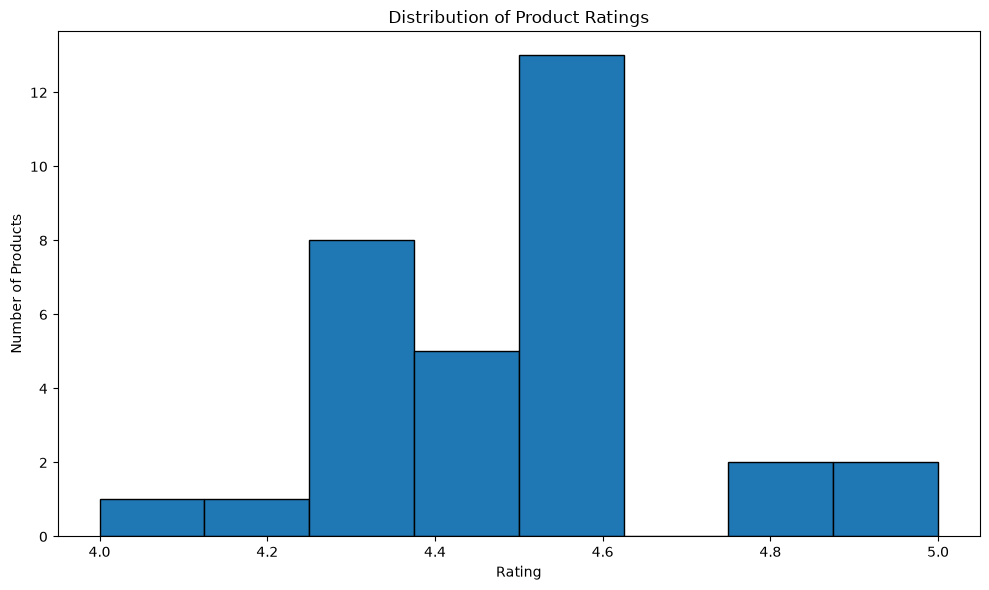

In [22]:
plt.figure(figsize=(10, 6))

plt.hist(
    products_df["rating"].dropna(),
    bins=8,
    edgecolor="black"
)

plt.title("Distribution of Product Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Products")
plt.tight_layout()
plt.show()

## Prime versus non-Prime summary

In [23]:
prime_summary_df = (
    products_df
    .assign(
        prime_status=np.where(
            products_df["is_prime"],
            "Prime",
            "Non-Prime"
        )
    )
    .groupby(
        "prime_status",
        as_index=False
    )
    .agg(
        product_count=("asin", "nunique"),
        average_price=("current_price", "mean"),
        average_rating=("rating", "mean"),
        total_reviews=("review_count", "sum")
    )
)

prime_summary_df[
    ["average_price", "average_rating"]
] = prime_summary_df[
    ["average_price", "average_rating"]
].round(2)

display(prime_summary_df)

,prime_status,product_count,average_price,average_rating,total_reviews
0,Non-Prime,32,59.66,4.47,701462


## Prime-status chart

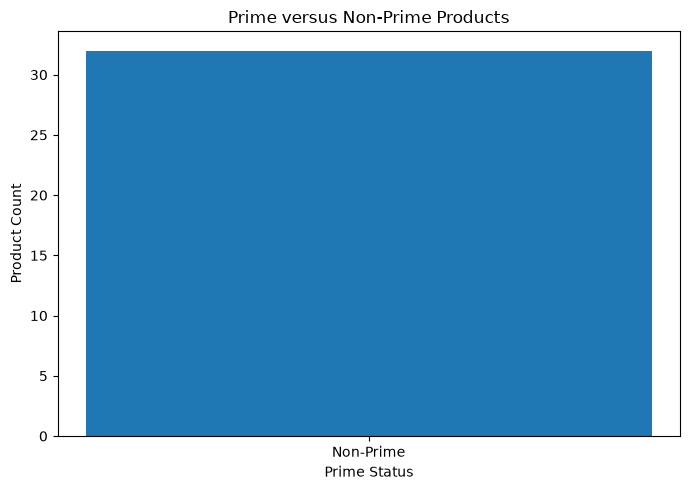

In [24]:
plt.figure(figsize=(7, 5))

plt.bar(
    prime_summary_df["prime_status"],
    prime_summary_df["product_count"]
)

plt.title("Prime versus Non-Prime Products")
plt.xlabel("Prime Status")
plt.ylabel("Product Count")
plt.tight_layout()
plt.show()

## Sponsored versus organic summary

In [25]:
sponsored_summary_df = (
    products_df
    .assign(
        listing_type=np.where(
            products_df["is_sponsored"],
            "Sponsored",
            "Organic"
        )
    )
    .groupby(
        "listing_type",
        as_index=False
    )
    .agg(
        product_count=("asin", "nunique"),
        average_price=("current_price", "mean"),
        average_rating=("rating", "mean"),
        total_reviews=("review_count", "sum")
    )
)

sponsored_summary_df[
    ["average_price", "average_rating"]
] = sponsored_summary_df[
    ["average_price", "average_rating"]
].round(2)

display(sponsored_summary_df)

,listing_type,product_count,average_price,average_rating,total_reviews
0,Organic,32,59.66,4.47,701462


## Top 10 products by review count

In [26]:
top_reviewed_products_df = (
    products_df[
        [
            "product_title",
            "brand",
            "current_price",
            "rating",
            "review_count",
            "price_category"
        ]
    ]
    .sort_values(
        by=[
            "review_count",
            "rating"
        ],
        ascending=[
            False,
            False
        ]
    )
    .head(10)
)

display(top_reviewed_products_df)

,product_title,brand,current_price,rating,review_count,price_category
15,soundcore by Anker P20i Kabellose Bluetooth Ko...,Soundcore,19.99,4.3,108356,Budget
16,soundcore by Anker P20i Kabellose Bluetooth Ko...,Soundcore,19.99,4.3,108356,Budget
17,soundcore by Anker Q20i kabelloser Bluetooth O...,Soundcore,29.99,4.6,67080,Budget
18,soundcore by Anker Q20i kabelloser Bluetooth O...,Soundcore,28.49,4.6,67080,Budget
26,"Btootos Bluetooth Kopfhörer, Kopfhörer Kabello...",Unknown,27.99,4.4,59613,Budget
10,Sony WH-CH520 Kabellose Bluetooth-Kopfhörer - ...,Sony,29.00,4.5,43481,Budget
11,Sony WH-CH520 Kabelloser Bluetooth On-Ear-Kopf...,Sony,29.56,4.5,43481,Budget
13,soundcore Anker P30i Kabellose Ohrhörer mit la...,Soundcore,29.99,4.3,34714,Budget
14,soundcore by Anker Liberty 4 NC Bluetooth-Kopf...,Soundcore,56.00,4.4,29680,Mid-range
19,"2026 Kopfhörer Kabellos Bluetooth 5.4, 6D Ster...",Unknown,24.49,4.5,24788,Budget


## Top-reviewed products chart

C:\Users\srika\AppData\Local\Temp\ipykernel_11804\1059572452.py:19: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


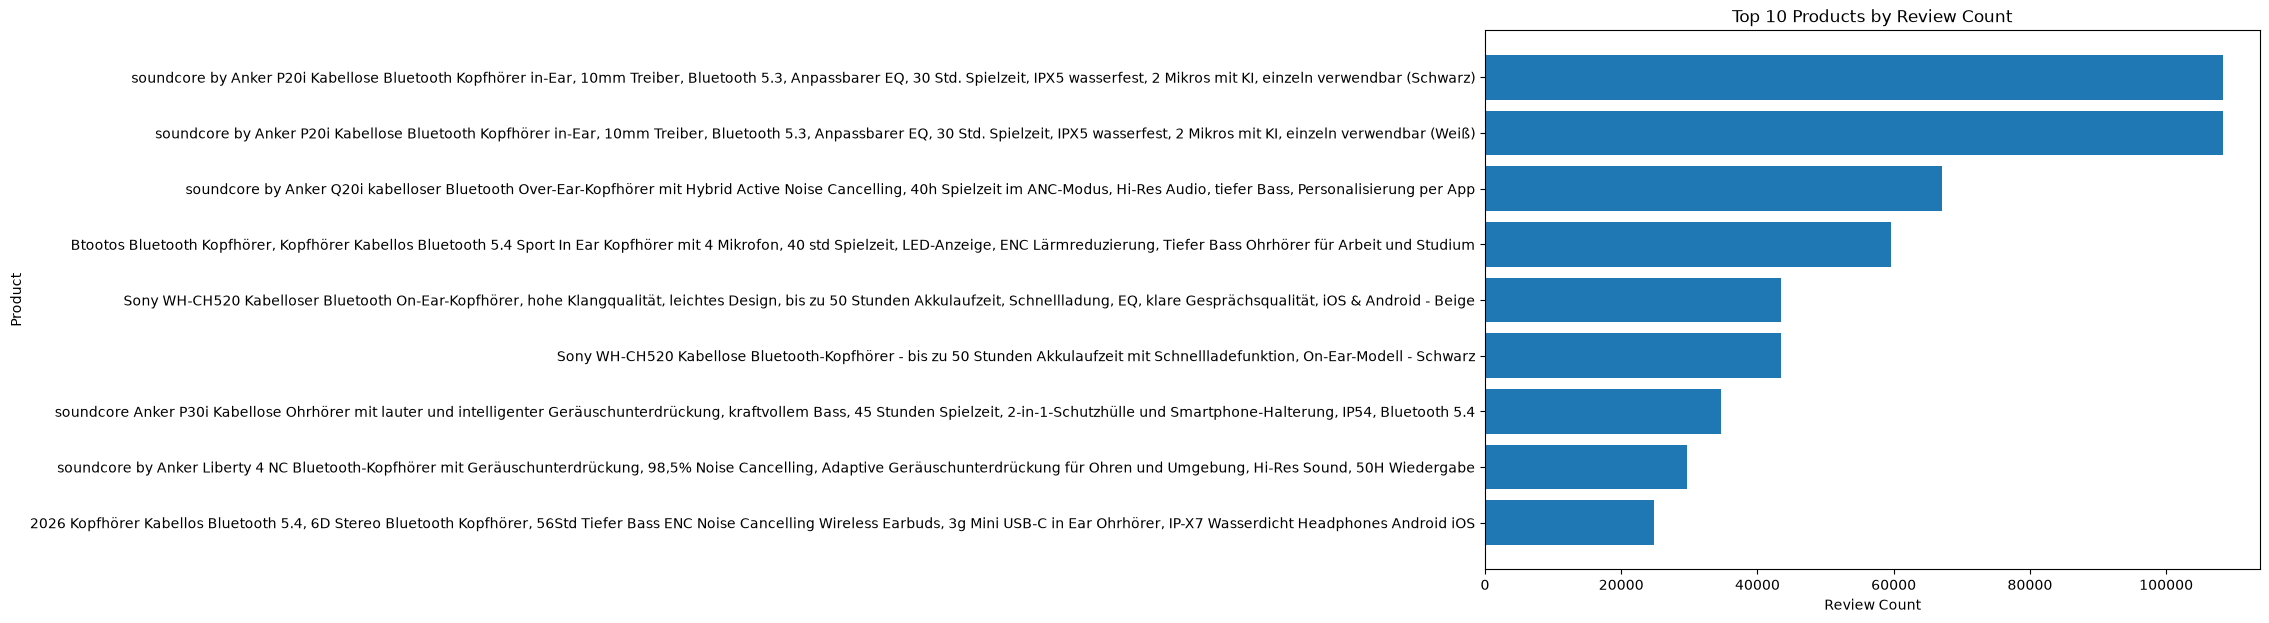

In [27]:
top_review_chart_df = (
    top_reviewed_products_df
    .sort_values(
        by="review_count",
        ascending=True
    )
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_review_chart_df["product_title"],
    top_review_chart_df["review_count"]
)

plt.title("Top 10 Products by Review Count")
plt.xlabel("Review Count")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

## Top-rated products

In [28]:
top_rated_products_df = (
    products_df[
        [
            "product_title",
            "brand",
            "current_price",
            "rating",
            "review_count"
        ]
    ]
    .sort_values(
        by=[
            "rating",
            "review_count"
        ],
        ascending=[
            False,
            False
        ]
    )
    .head(10)
)

display(top_rated_products_df)

,product_title,brand,current_price,rating,review_count
30,"yobola Kopfhörer Kabellos Bluetooth 5.4, In-Ea...",Unknown,23.99,5.0,48
22,"Bluetooth Kopfhörer, 2026 Kopfhörer Kabellos B...",Unknown,24.99,4.9,136
28,Over Ear Kopfhörer Bluetooth mit High-Resoluti...,Unknown,24.99,4.8,83
24,"Bluetooth Kopfhörer, Kopfhörer Kabellos Blueto...",Unknown,35.99,4.8,29
17,soundcore by Anker Q20i kabelloser Bluetooth O...,Soundcore,29.99,4.6,67080
18,soundcore by Anker Q20i kabelloser Bluetooth O...,Soundcore,28.49,4.6,67080
29,"Uliptz Bluetooth Kopfhörer Over Ear, 65 Stunde...",Unknown,15.97,4.6,14863
0,"Apple AirPods 4 Kabellose Kopfhörer, Bluetooth...",Apple,116.00,4.6,13612
2,JBL Tune 520 BT Wireless On-Ear Kopfhörer – Mi...,JBL,34.99,4.6,11360
27,Open Ear Bluetooth 6.1 KI Kopfhörer 50Std Spor...,Unknown,44.98,4.6,466


## Calculate correlation

In [29]:
price_rating_correlation = (
    products_df[
        ["current_price", "rating"]
    ]
    .corr()
    .loc[
        "current_price",
        "rating"
    ]
)

print(
    "Price-rating correlation:",
    round(price_rating_correlation, 4)
)

Price-rating correlation: -0.0102


## Scatter chart

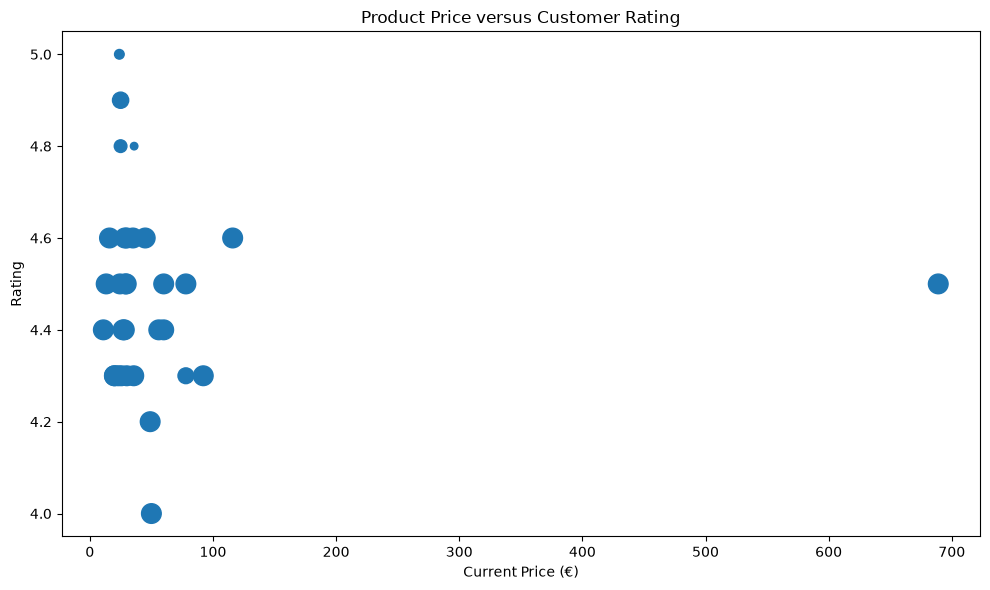

In [30]:
plt.figure(figsize=(10, 6))

plt.scatter(
    products_df["current_price"],
    products_df["rating"],
    s=products_df["review_count"].clip(
        lower=10,
        upper=200
    )
)

plt.title("Product Price versus Customer Rating")
plt.xlabel("Current Price (€)")
plt.ylabel("Rating")
plt.tight_layout()
plt.show()

## Create a value score

In [31]:
products_df["value_score"] = np.where(
    products_df["current_price"] > 0,
    (
        products_df["rating"]
        * np.log1p(products_df["review_count"])
    )
    / products_df["current_price"],
    np.nan
)

products_df["value_score"] = (
    products_df["value_score"]
    .round(4)
)

## Display top value products

In [32]:
top_value_products_df = (
    products_df[
        [
            "product_title",
            "brand",
            "current_price",
            "rating",
            "review_count",
            "value_score"
        ]
    ]
    .sort_values(
        by="value_score",
        ascending=False
    )
    .head(10)
)

display(top_value_products_df)

,product_title,brand,current_price,rating,review_count,value_score
9,"Bluetooth Kopfhörer, In Ear Kopfhörer Kabellos...",Samsung,10.99,4.4,1243,2.8530
29,"Uliptz Bluetooth Kopfhörer Over Ear, 65 Stunde...",Unknown,15.97,4.6,14863,2.7671
31,"ZZU Bluetooth Kopfhörer, Kopfhörer Kabellos Bl...",ZZU,13.29,4.5,2211,2.6078
15,soundcore by Anker P20i Kabellose Bluetooth Ko...,Soundcore,19.99,4.3,108356,2.4938
16,soundcore by Anker P20i Kabellose Bluetooth Ko...,Soundcore,19.99,4.3,108356,2.4938
19,"2026 Kopfhörer Kabellos Bluetooth 5.4, 6D Ster...",Unknown,24.49,4.5,24788,1.8592
18,soundcore by Anker Q20i kabelloser Bluetooth O...,Soundcore,28.49,4.6,67080,1.7944
26,"Btootos Bluetooth Kopfhörer, Kopfhörer Kabello...",Unknown,27.99,4.4,59613,1.7285
17,soundcore by Anker Q20i kabelloser Bluetooth O...,Soundcore,29.99,4.6,67080,1.7047
20,"Bluetooth 5.4 Kopfhörer Sport, 75Std 2026 Kopf...",Unknown,25.64,4.3,22976,1.6842


# Business Insights
## Create a summary of key results

In [33]:
most_common_brand = (
    brand_product_count.iloc[0]["brand"]
)

most_common_price_category = (
    products_df["price_category"]
    .value_counts()
    .idxmax()
)

highest_reviewed_product = (
    top_reviewed_products_df.iloc[0][
        "product_title"
    ]
)

highest_rated_product = (
    top_rated_products_df.iloc[0][
        "product_title"
    ]
)

analysis_summary = {
    "Most represented brand": most_common_brand,
    "Most common price category": (
        most_common_price_category
    ),
    "Highest reviewed product": (
        highest_reviewed_product
    ),
    "Highest rated product": (
        highest_rated_product
    ),
    "Price-rating correlation": round(
        price_rating_correlation,
        4
    )
}

analysis_summary_df = pd.DataFrame(
    analysis_summary.items(),
    columns=[
        "Insight Area",
        "Result"
    ]
)

display(analysis_summary_df)

,Insight Area,Result
0,Most represented brand,Unknown
1,Most common price category,Budget
2,Highest reviewed product,soundcore by Anker P20i Kabellose Bluetooth Ko...
3,Highest rated product,"yobola Kopfhörer Kabellos Bluetooth 5.4, In-Ea..."
4,Price-rating correlation,-0.0102


## Preliminary Business Insights

1. The market contains a mix of established brands and lesser-known sellers, indicating strong competitive variety.
2. The most common price category shows where the majority of products are positioned.
3. Products with the highest review counts may have stronger market visibility and customer familiarity.
4. Highly rated products are not always the most expensive, suggesting opportunities for value-focused positioning.
5. The price-rating correlation should be interpreted cautiously because the dataset contains a limited number of products.
6. Prime and sponsored listing status can be compared to understand whether visibility and fulfilment options are associated with stronger product performance.
7. The custom value score identifies products that combine rating, review volume and relatively affordable pricing.

## Export Analysis Results

In [34]:
analysis_export_file = (
    EXPORT_DIR
    / "amazon_product_analysis_results.xlsx"
)

with pd.ExcelWriter(
    analysis_export_file,
    engine="openpyxl"
) as writer:
    kpi_summary_df.to_excel(
        writer,
        sheet_name="KPI Summary",
        index=False
    )

    brand_performance_df.to_excel(
        writer,
        sheet_name="Brand Performance",
        index=False
    )

    price_category_summary.to_excel(
        writer,
        sheet_name="Price Categories",
        index=False
    )

    rating_category_summary.to_excel(
        writer,
        sheet_name="Rating Categories",
        index=False
    )

    prime_summary_df.to_excel(
        writer,
        sheet_name="Prime Analysis",
        index=False
    )

    sponsored_summary_df.to_excel(
        writer,
        sheet_name="Sponsored Analysis",
        index=False
    )

    top_reviewed_products_df.to_excel(
        writer,
        sheet_name="Top Reviewed",
        index=False
    )

    top_rated_products_df.to_excel(
        writer,
        sheet_name="Top Rated",
        index=False
    )

    top_value_products_df.to_excel(
        writer,
        sheet_name="Value Analysis",
        index=False
    )

print("Analysis Excel file saved successfully.")
print("Saved file:", analysis_export_file)

Analysis Excel file saved successfully.
Saved file: C:\Users\srika\Documents\Srikanth_Amazon_BI_Project\data\exports\amazon_product_analysis_results.xlsx


## Verify the exported file

In [35]:
print(
    "Analysis file exists:",
    analysis_export_file.exists()
)

print(
    "Analysis file size:",
    analysis_export_file.stat().st_size,
    "bytes"
)

Analysis file exists: True
Analysis file size: 13365 bytes
